 Stacked LSTM

### What is an LSTM?
LSTM (Long Short-Term Memory) is a type of Recurrent Neural Network (RNN) designed to learn
patterns from sequential data. Unlike traditional neural networks, LSTM maintains a **cell state**
that acts as memory, allowing it to capture long-range dependencies while avoiding the vanishing
gradient problem common in standard RNNs.

Each LSTM cell is controlled by three gates:
- **Forget gate** – decides what information to discard from memory
- **Input gate** – decides what new information to store
- **Output gate** – decides what to pass to the next step

---

### What is a Stacked LSTM?
A Stacked LSTM is multiple LSTM layers placed on top of each other, where the output of one
LSTM layer becomes the input of the next. This depth allows the model to learn more abstract
and complex patterns from the data.

In this model:
- **Layer 1:** LSTM(64 units) — learns low-level temporal patterns, passes full sequence forward via `return_sequences=True`
- **Layer 2:** LSTM(32 units) — learns higher-level abstractions, returns only the final hidden state
- **Dropout(0.3)** after each LSTM layer — prevents overfitting by randomly deactivating 30% of neurons during training
- **Dense(1, sigmoid)** — outputs a probability score for binary classification

---

### Why Stacked LSTM for this dataset?
Although our dataset `(109474, 31)` is tabular (not a natural time series), we reshape each
sample into `(1, 31)` — treating the 31 features as one timestep. The Stacked LSTM is used here
to benchmark deep sequential learning against traditional models like Random Forest, and to
compare with other LSTM variants (Bidirectional, CNN-LSTM, etc.).



Reloading Tuner from ./untitled_project/tuner0.json

 Best Hyperparameters — Stacked LSTM:
  LSTM units layer 1 : 128
  LSTM units layer 2 : 32
  Dropout layer 1    : 0.1
  Dropout layer 2    : 0.4
  Optimizer          : adam
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1369/1369 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.0263 - val_loss: 0.0128
Epoch 2/30
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.0181 - val_loss: 0.0128
Epoch 3/30
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0180 - val_loss: 0.0128
Epoch 4/30
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.0181 - val_loss: 0.0128
Epoch 5/30
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0180 - val_loss: 0.0128
Epoch 6/30
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0181 - val_loss: 0.0129
Epoch 7/30
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0179 - val_loss: 0.0128
Epoch 8/30
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.0178 - val_loss: 0.0128
Epoch 9/30
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0175 - val_loss: 0.0128
Epoch 10/30
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0180 - val_loss: 0.0128
Epoch 11/30
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0181 - val_loss: 0.0128
Epoch 12/30
1369/1369 ━━━━━━━━━━━

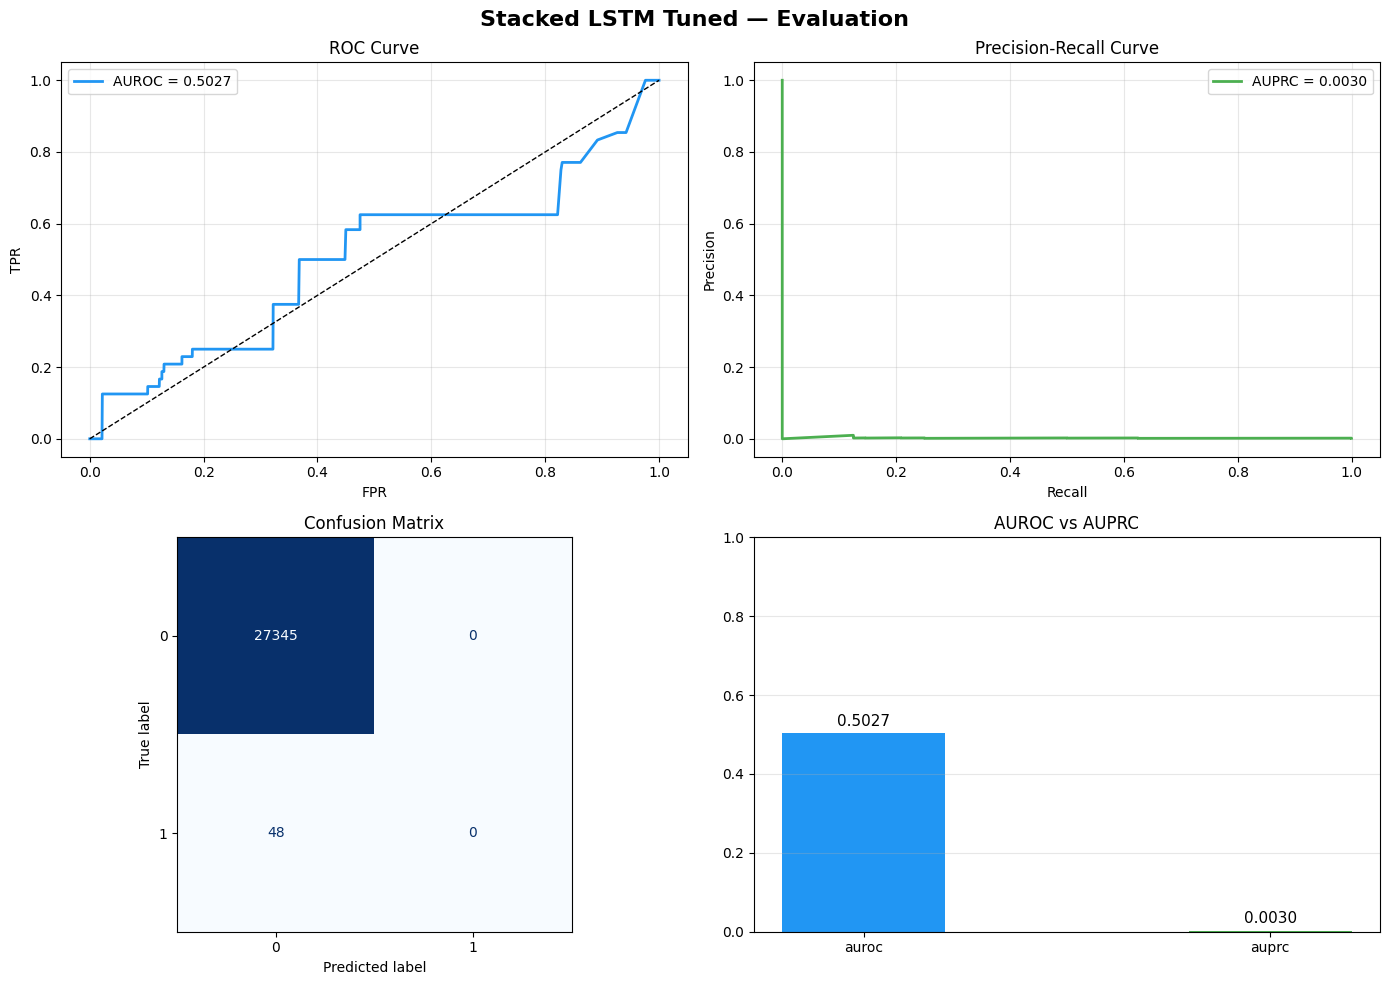

In [20]:

import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout,Bidirectional
from sklearn.metrics import roc_auc_score, average_precision_score
from keras_tuner import RandomSearch
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

path = "/content/"
#importing data and transform into vector
X_train=pd.read_csv(path + "X_train.csv").values
X_test=pd.read_csv(path + "X_test.csv").values
y_train=pd.read_csv(path + "y_train.csv").values.ravel()
y_test=pd.read_csv(path + "y_test.csv").values.ravel()
results={}
X_train_r = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_r  = X_test.reshape(X_test.shape[0],  1, X_test.shape[1])

def plot_results(y_test, y_prob, y_pred, metrics, title, colors, filename):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=16, fontweight="bold")

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0, 0].plot(fpr, tpr, color=colors[0], linewidth=2, label=f"AUROC = {metrics['auroc']:.4f}")
    axes[0, 0].plot([0, 1], [0, 1], 'k--', linewidth=1)
    axes[0, 0].set_title("ROC Curve")
    axes[0, 0].set_xlabel("FPR"); axes[0, 0].set_ylabel("TPR")
    axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    axes[0, 1].plot(rec, prec, color=colors[1], linewidth=2, label=f"AUPRC = {metrics['auprc']:.4f}")
    axes[0, 1].set_title("Precision-Recall Curve")
    axes[0, 1].set_xlabel("Recall"); axes[0, 1].set_ylabel("Precision")
    axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot(ax=axes[1, 0], colorbar=False, cmap="Blues")
    axes[1, 0].set_title("Confusion Matrix")

    axes[1, 1].bar(metrics.keys(), metrics.values(), color=colors, width=0.4)
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].set_title("AUROC vs AUPRC")
    for i, (k, v) in enumerate(metrics.items()):
        axes[1, 1].text(i, v + 0.02, f"{v:.4f}", ha='center', fontsize=11)
    axes[1, 1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()

def build_stack_lstm(hp):
    model = Sequential([
        LSTM(
            units            = hp.Int('units_1', min_value=32, max_value=128, step=32),
            input_shape      = (1, X_train.shape[1]),
            return_sequences = True),
        Dropout(hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)),
        LSTM(
            units            = hp.Int('units_2', min_value=16, max_value=64, step=16)),
        Dropout(hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer = hp.Choice('optimizer', ['adam', 'rmsprop']),
        loss      = 'binary_crossentropy'
    )
    return model

def tune_stack_lstm(X_train_r, X_test_r, y_train, y_test):
    tuner = RandomSearch(
        build_stack_lstm,
        objective            = 'val_loss',
        max_trials           = 10,
        executions_per_trial = 1,

    )

    tuner.search(
        X_train_r, y_train,
        epochs           = 10,
        batch_size       = 64,
        validation_split = 0.2,
        verbose          = 1,
        callbacks        = [EarlyStopping(monitor='val_loss', patience=3)]
    )

    best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
    print("\n Best Hyperparameters — Stacked LSTM:")
    print(f"  LSTM units layer 1 : {best_hp.get('units_1')}")
    print(f"  LSTM units layer 2 : {best_hp.get('units_2')}")
    print(f"  Dropout layer 1    : {best_hp.get('dropout_1')}")
    print(f"  Dropout layer 2    : {best_hp.get('dropout_2')}")
    print(f"  Optimizer          : {best_hp.get('optimizer')}")

    best_model = build_stack_lstm(best_hp)
    best_model.fit(
        X_train_r, y_train,
        epochs           = 30,
        batch_size       = 64,
        validation_split = 0.2,
        verbose          = 1,
        callbacks        = [EarlyStopping(monitor='val_loss', patience=3)]
    )

    y_prob = best_model.predict(X_test_r).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        "auroc": roc_auc_score(y_test, y_prob),
        "auprc": average_precision_score(y_test, y_prob)
    }

    for k, v in metrics.items():
        print(f"[Stacked LSTM Tuned] {k}: {v:.4f}")

    results["StackedLSTM_Tuned"] = metrics

    plot_results(
        y_test, y_prob, y_pred, metrics,
        title    = "Stacked LSTM Tuned — Evaluation",
        colors   = ["#2196F3", "#4CAF50"],
        filename = "stack_lstm_tuned_results.png"
    )
    best_model.save("best_stack_lstm.keras")


tune_stack_lstm(X_train_r, X_test_r, y_train, y_test)



Here's the Markdown explanation for your notebook:
markdown## 3. Bidirectional LSTM (BiLSTM)

### What is a Bidirectional LSTM?
A Bidirectional LSTM (BiLSTM) is an extension of the standard LSTM that processes the input
sequence in **two directions simultaneously**:
- **Forward direction** → reads the sequence from left to right
- **Backward direction** → reads the sequence from right to left

The outputs of both directions are then **concatenated**, giving the model access to both
past and future context at every timestep. This makes BiLSTM more powerful than a standard
LSTM when the relationship between features is not strictly directional.

---

### How is it different from Stacked LSTM?

| | Stacked LSTM | BiLSTM |
|---|---|---|
| Direction | Forward only | Forward + Backward |
| Output size | 64 / 32 units | 128 / 64 units (doubled) |
| Context | Past context only | Past + Future context |
| Complexity | Lower | Higher |

In Stacked LSTM, `LSTM(64)` outputs 64 units.
In BiLSTM, `Bidirectional(LSTM(64))` outputs **128 units** — 64 from each direction.

---

### Model Architecture
- **Layer 1:** Bidirectional(LSTM(64)) — processes sequence forward and backward, outputs 128 units
- **Layer 2:** Bidirectional(LSTM(32)) — deeper abstraction, outputs 64 units
- **Dropout(0.3)** after each layer — regularization to prevent overfitting
- **Dense(1, sigmoid)** — final binary classification output

---

### Why BiLSTM for this dataset?
Although our data `(109474, 31)` is tabular and reshaped to `(1, 31)` — meaning only one
timestep — the BiLSTM is still useful here because it learns feature relationships from
both ends of the feature vector simultaneously, which can capture patterns that a
unidirectional LSTM might miss.

BiLSTM is particularly powerful when:
- The data has natural sequential order (time series, text)
- Future context is as important as past context
- The model needs richer feature representations

Reloading Tuner from ./untitled_project/tuner0.json

 Best Hyperparameters — BiLSTM:
  LSTM units layer 1 : 128
  LSTM units layer 2 : 32
  Dropout layer 1    : 0.1
  Dropout layer 2    : 0.4
  Optimizer          : adam
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1369/1369 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 0.0207 - val_loss: 0.0128
Epoch 2/30
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 0.0177 - val_loss: 0.0128
Epoch 3/30
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.0177 - val_loss: 0.0128
Epoch 4/30
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.0177 - val_loss: 0.0128
Epoch 5/30
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.0178 - val_loss: 0.0127
Epoch 6/30
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.0175 - val_loss: 0.0128
Epoch 7/30
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.0176 - val_loss: 0.0127
Epoch 8/30
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 0.0176 - val_loss: 0.0128
857/857 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
[BiLSTM Tuned] auroc: 0.5377
[BiLSTM Tuned] auprc: 0.0026


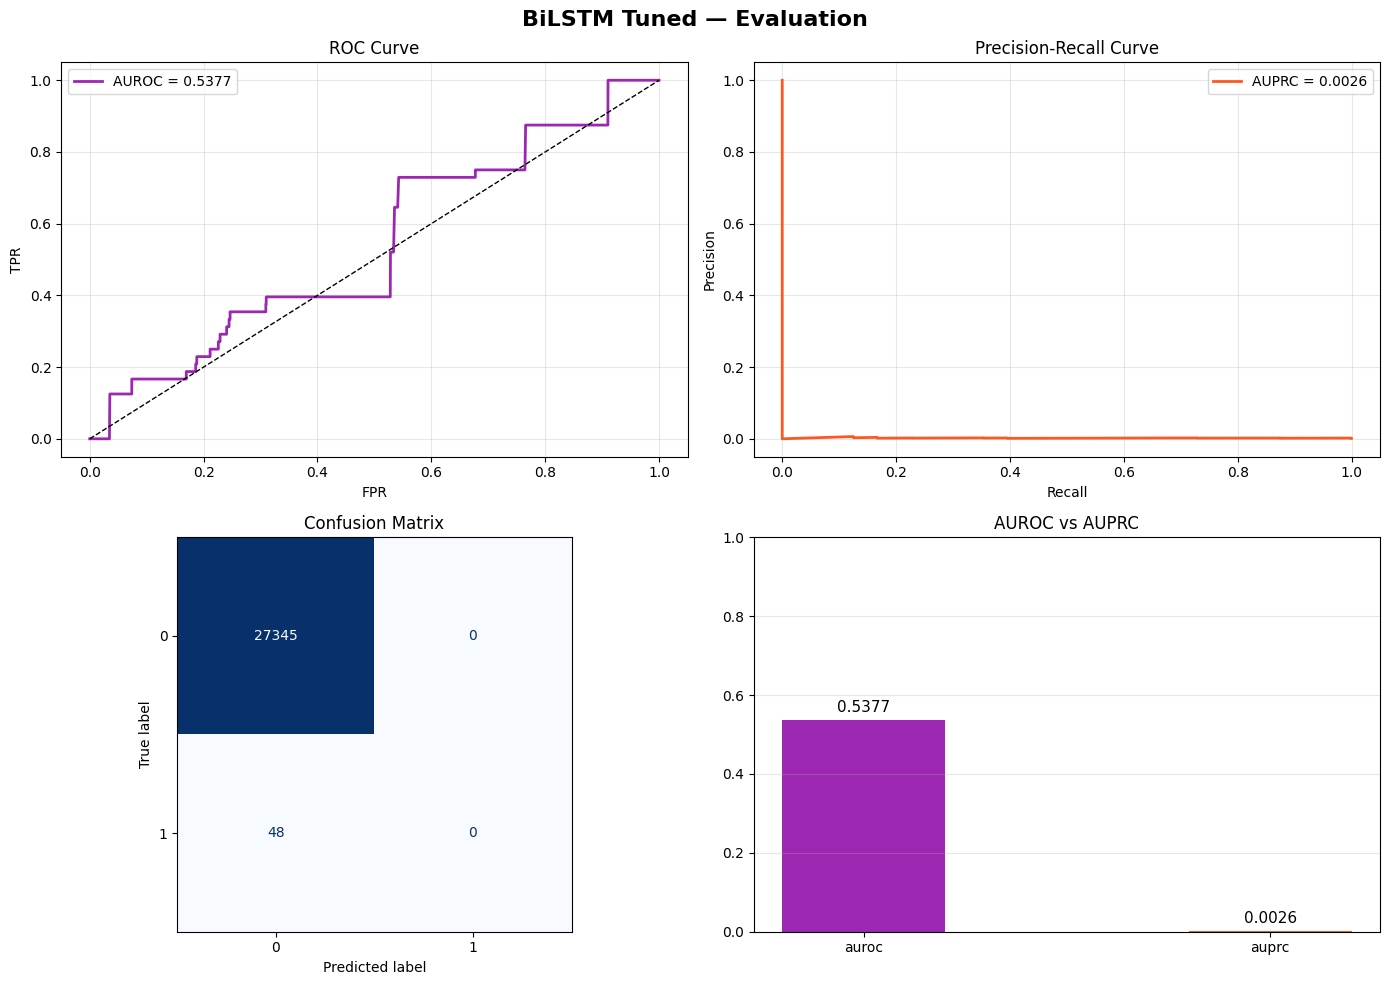

In [22]:


def build_bilstm(hp):
    model = Sequential([
        Bidirectional(LSTM(
            units= hp.Int('units_1', min_value=32, max_value=128, step=32),
            return_sequences = True),
            input_shape=(1, X_train.shape[1])),
        Dropout(hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)),
        Bidirectional(LSTM(
            units            = hp.Int('units_2', min_value=16, max_value=64, step=16))),
        Dropout(hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer = hp.Choice('optimizer', ['adam', 'rmsprop']),
        loss      = 'binary_crossentropy'
    )
    return model

def tune_bilstm(X_train_r, X_test_r, y_train, y_test):
    tuner = RandomSearch(
        build_bilstm,
        objective            = 'val_loss',
        max_trials           = 10,
        executions_per_trial = 1,

    )

    tuner.search(
        X_train_r, y_train,
        epochs           = 10,
        batch_size       = 64,
        validation_split = 0.2,
        verbose          = 1,
        callbacks        = [EarlyStopping(monitor='val_loss', patience=3)]
    )

    best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
    print("\n Best Hyperparameters — BiLSTM:")
    print(f"  LSTM units layer 1 : {best_hp.get('units_1')}")
    print(f"  LSTM units layer 2 : {best_hp.get('units_2')}")
    print(f"  Dropout layer 1    : {best_hp.get('dropout_1')}")
    print(f"  Dropout layer 2    : {best_hp.get('dropout_2')}")
    print(f"  Optimizer          : {best_hp.get('optimizer')}")

    best_model = build_bilstm(best_hp)
    best_model.fit(
        X_train_r, y_train,
        epochs           = 30,
        batch_size       = 64,
        validation_split = 0.2,
        verbose          = 1,
        callbacks        = [EarlyStopping(monitor='val_loss', patience=3)]
    )

    y_prob = best_model.predict(X_test_r).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        "auroc": roc_auc_score(y_test, y_prob),
        "auprc": average_precision_score(y_test, y_prob)
    }

    for k, v in metrics.items():
        print(f"[BiLSTM Tuned] {k}: {v:.4f}")

    results["BiLSTM_Tuned"] = metrics

    plot_results(
        y_test, y_prob, y_pred, metrics,
        title    = "BiLSTM Tuned — Evaluation",
        colors   = ["#9C27B0", "#FF5722"],
        filename = "bilstm_tuned_results.png"
    )
    best_model.save("best_bilstm.keras")


tune_bilstm(X_train_r, X_test_r, y_train, y_test)